In [2]:
import pandas as pd

# Read the restaurant names and metadata file
metadata_df = pd.read_csv('Zomato Restaurant names and Metadata (1).csv')

# Read the restaurant reviews file
reviews_df = pd.read_csv('Zomato Restaurant reviews (1).csv')

# Display the first few rows of the metadata dataframe to make sure it loaded correctly
metadata_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [3]:
# Check for null values in the metadata dataframe
print("--- Metadata DF Null Values ---")
print(metadata_df.isnull().sum())

print("\n--- Reviews DF Null Values ---")
# Check for null values in the reviews dataframe
print(reviews_df.isnull().sum())

--- Metadata DF Null Values ---
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

--- Reviews DF Null Values ---
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64


In [4]:
# Drop rows where critical review data is missing
reviews_df.dropna(subset=['Reviewer', 'Rating', 'Time'], inplace=True)

# Verify the changes
print("Remaining nulls in reviews:")
print(reviews_df.isnull().sum())

Remaining nulls in reviews:
Restaurant    0
Reviewer      0
Review        7
Rating        0
Metadata      0
Time          0
Pictures      0
dtype: int64


In [5]:
# Fill missing Collections with 'None'
metadata_df['Collections'].fillna('None', inplace=True)

# Fill missing Review text with a placeholder if any remain
reviews_df['Review'].fillna('No text provided', inplace=True)

# Check metadata nulls again
print("Remaining nulls in metadata:")
print(metadata_df.isnull().sum())

Remaining nulls in metadata:
Name           0
Links          0
Cost           0
Collections    0
Cuisines       0
Timings        1
dtype: int64


/tmp/ipykernel_1350/206490457.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata_df['Collections'].fillna('None', inplace=True)
/tmp/ipykernel_1350/206490457.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [6]:
# Check for duplicate rows
print(f"Metadata duplicates: {metadata_df.duplicated().sum()}")
print(f"Reviews duplicates: {reviews_df.duplicated().sum()}")

# Check data types and general info
print("\n--- Metadata Info ---")
metadata_df.info()

Metadata duplicates: 0
Reviews duplicates: 0

--- Metadata Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  105 non-null    object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


In [7]:
# 1. Clean and convert the 'Cost' column to numeric
metadata_df['Cost'] = metadata_df['Cost'].str.replace(',', '').astype(float)

# 2. Check the info for the reviews dataframe to see its data types
print("--- Reviews DF Info ---")
reviews_df.info()

# 3. Quick statistical summary of the cleaned numerical data
print("\n--- Metadata Summary ---")
print(metadata_df.describe())

--- Reviews DF Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 9962 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  9962 non-null   object
 1   Reviewer    9962 non-null   object
 2   Review      9962 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    9962 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 622.6+ KB

--- Metadata Summary ---
              Cost
count   105.000000
mean    861.428571
std     510.149730
min     150.000000
25%     500.000000
50%     700.000000
75%    1200.000000
max    2800.000000


In [8]:
# 1. Print unique ratings to see if there are non-numeric strings (like "Like" or "Rated")
print("Unique rating values before cleaning:")
print(reviews_df['Rating'].unique()[:20])  # Look at the first 20 unique entries

# 2. Convert Rating to numeric, turning any invalid text into NaN (missing values)
reviews_df['Rating'] = pd.to_numeric(reviews_df['Rating'], errors='coerce')

# 3. Check if the conversion introduced any new null values we need to drop
print("\nNull values in Reviews DF after rating conversion:")
print(reviews_df.isnull().sum())

# 4. Drop any rows where Rating became NaN due to invalid text
reviews_df.dropna(subset=['Rating'], inplace=True)

print("\n--- Final Cleaned Reviews Summary ---")
print(reviews_df['Rating'].describe())

Unique rating values before cleaning:
['5' '4' '1' '3' '2' '3.5' '4.5' '2.5' '1.5' 'Like']

Null values in Reviews DF after rating conversion:
Restaurant    0
Reviewer      0
Review        0
Rating        1
Metadata      0
Time          0
Pictures      0
dtype: int64

--- Final Cleaned Reviews Summary ---
count    9961.000000
mean        3.601044
std         1.483461
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: Rating, dtype: float64


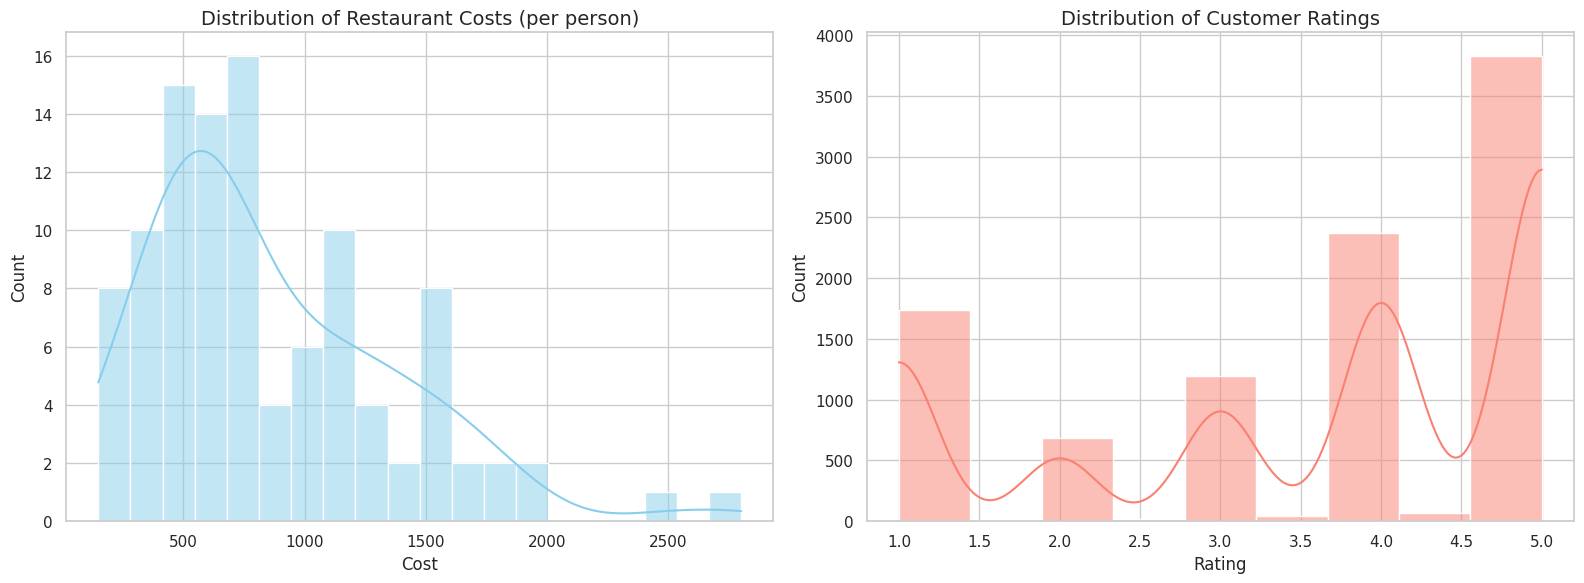

--- Quick Summary Metrics ---
Average Cost: ₹861.43
Most Common Cost (Median): ₹700.00
Average Rating: 3.60 / 5.0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for clean, sharp visualizations
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot the distribution of Restaurant Costs
sns.histplot(metadata_df['Cost'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Restaurant Costs (per person)', fontsize=14)
axes[0].set_xlabel('Cost', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# 2. Plot the distribution of Customer Ratings
sns.histplot(reviews_df['Rating'], bins=9, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Customer Ratings', fontsize=14)
axes[1].set_xlabel('Rating', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

# Quick statistical overview of the key metrics
print("--- Quick Summary Metrics ---")
print(f"Average Cost: ₹{metadata_df['Cost'].mean():.2f}")
print(f"Most Common Cost (Median): ₹{metadata_df['Cost'].median():.2f}")
print(f"Average Rating: {reviews_df['Rating'].mean():.2f} / 5.0")

/tmp/ipykernel_1350/3344278399.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_counts.head(15).values, y=cuisine_counts.head(15).index, palette='viridis')


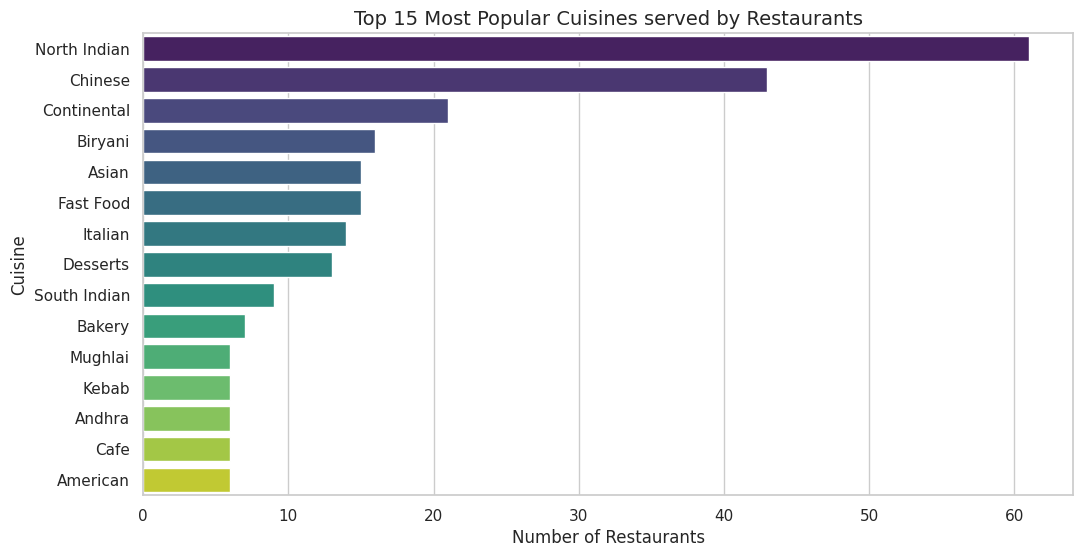

--- Top 5 Most Common Cuisines ---
Cuisines
North Indian    61
Chinese         43
Continental     21
Biryani         16
Asian           15
Name: count, dtype: int64


In [10]:



# 1. Split the comma-separated cuisines and flatten them into a single series
all_cuisines = metadata_df['Cuisines'].str.split(', ').explode()

# 2. Count the occurrences of each cuisine
cuisine_counts = all_cuisines.value_counts()

# 3. Plot the top 15 most frequent cuisines
plt.figure(figsize=(12, 6))
sns.barplot(x=cuisine_counts.head(15).values, y=cuisine_counts.head(15).index, palette='viridis')

plt.title('Top 15 Most Popular Cuisines served by Restaurants', fontsize=14)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Cuisine', fontsize=12)
plt.show()

# Print the top 5 cuisines explicitly
print("--- Top 5 Most Common Cuisines ---")
print(cuisine_counts.head(5))

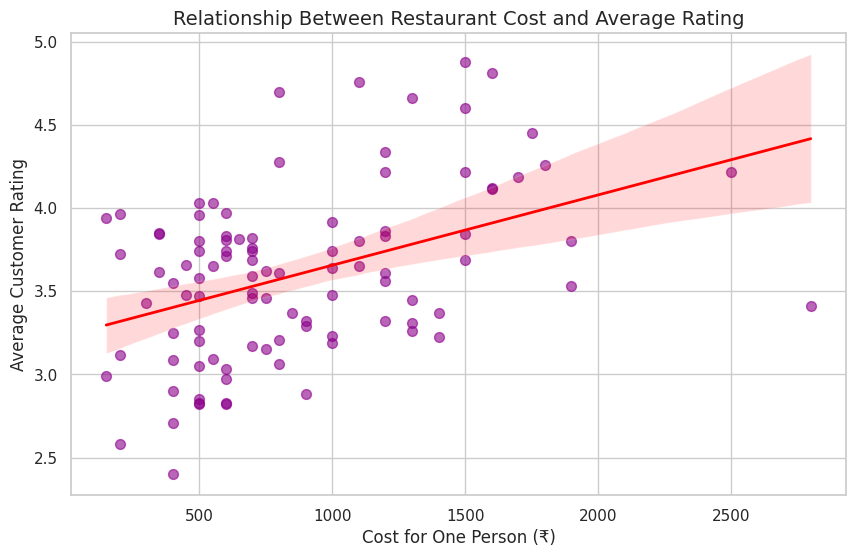

Correlation between Cost and Rating: 0.42


In [11]:
# 1. Calculate the average rating for each restaurant from the reviews dataset
avg_ratings = reviews_df.groupby('Restaurant')['Rating'].mean().reset_index()

# 2. Merge the average ratings with the metadata dataset
# We map 'Restaurant' from the reviews to 'Name' in the metadata
merged_df = pd.merge(metadata_df, avg_ratings, left_on='Name', right_on='Restaurant', how='inner')

# 3. Plot a scatter plot with a trend line to see if cost impacts ratings
plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df, x='Cost', y='Rating', color='darkmagenta',
            scatter_kws={'alpha':0.6, 's':50}, line_kws={'color':'red', 'lw':2})

plt.title('Relationship Between Restaurant Cost and Average Rating', fontsize=14)
plt.xlabel('Cost for One Person (₹)', fontsize=12)
plt.ylabel('Average Customer Rating', fontsize=12)
plt.show()

# 4. Calculate the correlation coefficient to get a precise statistical metric
correlation = merged_df['Cost'].corr(merged_df['Rating'])
print(f"Correlation between Cost and Rating: {correlation:.2f}")

In [12]:
# 1. Clean up cuisine strings and get a list of unique cuisines
merged_df['Cuisines'] = merged_df['Cuisines'].apply(lambda x: [c.strip() for c in x.split(',')])

# 2. Use pandas explode and get_dummies to one-hot encode the cuisines
cuisines_encoded = merged_df['Cuisines'].explode().str.get_dummies().groupby(level=0).sum()

# 3. Combine the encoded cuisines back with our primary numerical features (Cost and Rating)
# This creates our final feature matrix for clustering
features_df = pd.concat([merged_df[['Cost', 'Rating']], cuisines_encoded], axis=1)

# Display the first few rows of your new numerical feature matrix
print("--- Final Feature Matrix for Clustering ---")
print(f"Shape of feature matrix: {features_df.shape}")
features_df.head()

--- Final Feature Matrix for Clustering ---
Shape of feature matrix: (100, 44)


,Cost,Rating,American,Andhra,Arabian,Asian,BBQ,Bakery,Beverages,Biryani,...,North Indian,Pizza,Salad,Seafood,South Indian,Spanish,Street Food,Sushi,Thai,Wraps
0,800.0,4.28,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
1,800.0,4.70,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
2,1300.0,4.66,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,800.0,3.21,0,0,0,0,0,0,1,1,...,1,0,0,1,0,0,0,0,0,0
4,1200.0,4.34,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [13]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit and transform the feature matrix to scale the data uniformly
scaled_features = scaler.fit_transform(features_df)

# 3. Convert back to a DataFrame for easy handling and verify the format
scaled_features_df = pd.DataFrame(scaled_features, columns=features_df.columns)

print("--- Scaled Feature Matrix ---")
print(f"Shape: {scaled_features_df.shape}")
scaled_features_df.head()


--- Scaled Feature Matrix ---
Shape: (100, 44)


,Cost,Rating,American,Andhra,Arabian,Asian,BBQ,Bakery,Beverages,Biryani,...,North Indian,Pizza,Salad,Seafood,South Indian,Spanish,Street Food,Sushi,Thai,Wraps
0,-0.143026,1.340330,-0.252646,-0.252646,-0.142857,-0.403473,-0.142857,-0.252646,-0.229416,-0.420084,...,0.816497,-0.100504,-0.204124,-0.204124,3.179797,-0.100504,-0.142857,-0.204124,-0.142857,-0.100504
1,-0.143026,2.171454,-0.252646,-0.252646,-0.142857,-0.403473,-0.142857,-0.252646,-0.229416,2.380476,...,0.816497,-0.100504,-0.204124,-0.204124,-0.314485,-0.100504,-0.142857,-0.204124,-0.142857,-0.100504
2,0.850211,2.092300,-0.252646,-0.252646,-0.142857,2.478479,-0.142857,-0.252646,-0.229416,-0.420084,...,0.816497,-0.100504,-0.204124,-0.204124,-0.314485,-0.100504,-0.142857,-0.204124,-0.142857,-0.100504
3,-0.143026,-0.777059,-0.252646,-0.252646,-0.142857,-0.403473,-0.142857,-0.252646,4.358899,2.380476,...,0.816497,-0.100504,-0.204124,4.898979,-0.314485,-0.100504,-0.142857,-0.204124,-0.142857,-0.100504
4,0.651564,1.459062,-0.252646,-0.252646,-0.142857,2.478479,-0.142857,-0.252646,-0.229416,-0.420084,...,0.816497,-0.100504,-0.204124,-0.204124,-0.314485,-0.100504,-0.142857,-0.204124,-0.142857,-0.100504


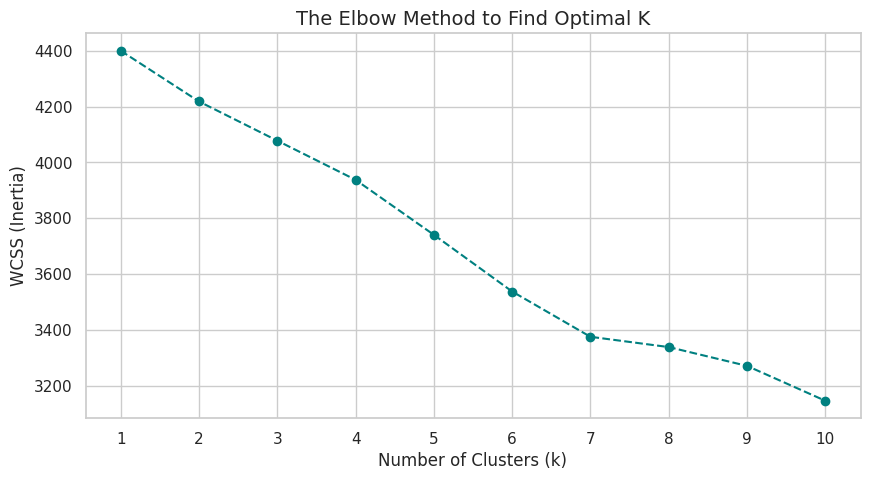

In [14]:
from sklearn.cluster import KMeans

# 1. Calculate WCSS (inertia) for different numbers of clusters
wcss = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# 2. Plot the Elbow graph
plt.figure(figsize=(10, 5))
plt.plot(cluster_range, wcss, marker='o', linestyle='--', color='teal')
plt.title('The Elbow Method to Find Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(cluster_range)
plt.show()

In [15]:
# 1. Initialize and fit the final K-Means model with 7 clusters
optimal_k = 7
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
merged_df['Cluster'] = kmeans_final.fit_transform(scaled_features).argmin(axis=1) # Assigns cluster labels

# 2. Check how many restaurants fell into each cluster
print("--- Restaurant Count Per Cluster ---")
print(merged_df['Cluster'].value_counts().sort_index())

# 3. View a quick sample of restaurants from each cluster to see if they look similar
print("\n--- Sample Restaurants from Each Cluster ---")
for i in range(optimal_k):
    print(f"\nCluster {i} Examples:")
    print(merged_df[merged_df['Cluster'] == i]['Name'].head(3).tolist())

--- Restaurant Count Per Cluster ---
Cluster
0     4
1    15
2     1
3     2
4    45
5    32
6     1
Name: count, dtype: int64

--- Sample Restaurants from Each Cluster ---

Cluster 0 Examples:
['Kritunga Restaurant', 'Yum Yum Tree - The Arabian Food Court', 'Al Saba Restaurant']

Cluster 1 Examples:
['Cream Stone', 'Amul', 'Deli 9 Bistro']

Cluster 2 Examples:
["The Fisherman's Wharf"]

Cluster 3 Examples:
['Feast - Sheraton Hyderabad Hotel', 'The Indi Grill']

Cluster 4 Examples:
['Paradise', 'Shah Ghouse Hotel & Restaurant', 'Shah Ghouse Spl Shawarma']

Cluster 5 Examples:
['Beyond Flavours', 'Flechazo', 'Over The Moon Brew Company']

Cluster 6 Examples:
['Shanghai Chef 2']


In [16]:





# 1. Calculate the average Cost and Rating for each cluster
cluster_profile = merged_df.groupby('Cluster')[['Cost', 'Rating']].mean()

# 2. Add the total number of restaurants in each cluster for context
cluster_profile['Restaurant_Count'] = merged_df['Cluster'].value_counts()

print("--- Cluster Profiles (Cost & Rating Averages) ---")
print(cluster_profile.sort_index())

# 3. Identify the most dominant cuisine features inside each cluster
print("\n--- Dominant Characteristics per Cluster ---")
for i in range(optimal_k):
    cluster_data = merged_df[merged_df['Cluster'] == i]

    # Re-flatten the cuisines list for this specific cluster to see what's popular inside it
    cluster_cuisines = cluster_data['Cuisines'].explode().value_counts().head(3)

    print(f"\n★ CLUSTER {i} ★")
    print(f"  Total Restaurants: {len(cluster_data)}")
    print(f"  Average Cost: ₹{cluster_data['Cost'].mean():.2f}")
    print(f"  Average Rating: {cluster_data['Rating'].mean():.2f}")
    print("  Top Cuisines served:")
    for cuisine, count in cluster_cuisines.items():
        print(f"    - {cuisine} ({count} restaurants)")

--- Cluster Profiles (Cost & Rating Averages) ---
                Cost    Rating  Restaurant_Count
Cluster                                         
0         762.500000  3.503750                 4
1         516.666667  3.622411                15
2        1500.000000  4.220000                 1
3        2000.000000  4.410000                 2
4         616.666667  3.366645                45
5        1323.437500  3.884926                32
6         800.000000  3.060000                 1

--- Dominant Characteristics per Cluster ---

★ CLUSTER 0 ★
  Total Restaurants: 4
  Average Cost: ₹762.50
  Average Rating: 3.50
  Top Cuisines served:
    - Hyderabadi (4 restaurants)
    - North Indian (3 restaurants)
    - Biryani (2 restaurants)

★ CLUSTER 1 ★
  Total Restaurants: 15
  Average Cost: ₹516.67
  Average Rating: 3.62
  Top Cuisines served:
    - Desserts (12 restaurants)
    - Cafe (6 restaurants)
    - Fast Food (6 restaurants)

★ CLUSTER 2 ★
  Total Restaurants: 1
  Average Cost: ₹15

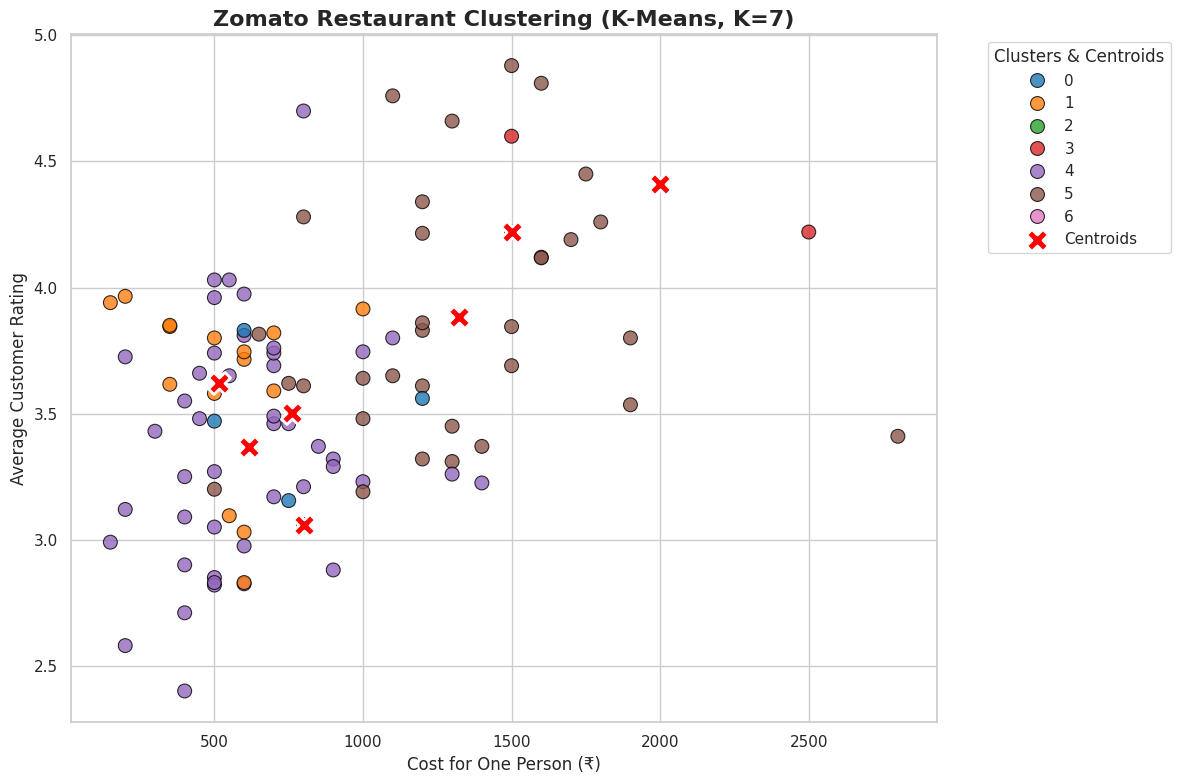

In [17]:
# 1. Calculate the cluster centroids for Cost and Rating
# Since we fit KMeans on scaled data, we calculate centers on the original scale for presentation clarity
centroids = merged_df.groupby('Cluster')[['Cost', 'Rating']].mean().reset_index()

# 2. Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=merged_df,
    x='Cost',
    y='Rating',
    hue='Cluster',
    palette='tab10',
    s=100,
    alpha=0.8,
    edgecolor='black'
)

# 3. Plot the cluster centers as prominent red 'X' markers
plt.scatter(
    centroids['Cost'],
    centroids['Rating'],
    color='red',
    marker='X',
    s=250,
    label='Centroids',
    edgecolor='white',
    linewidth=2
)

# 4. Format the chart for your presentation
plt.title('Zomato Restaurant Clustering (K-Means, K=7)', fontsize=16, fontweight='bold')
plt.xlabel('Cost for One Person (₹)', fontsize=12)
plt.ylabel('Average Customer Rating', fontsize=12)
plt.legend(title='Clusters & Centroids', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [18]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Download the VADER lexicon package
nltk.download('vader_lexicon')

# 2. Initialize the Sentiment Intensity Analyzer
sia = SentimentIntensityAnalyzer()

# 3. Define a function to categorize the compound score
def get_sentiment_category(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# 4. Calculate sentiment scores on the clean review text column
# This might take a few seconds due to the ~10k rows
print("Analyzing review sentiments... Please wait.")
reviews_df['Sentiment_Score'] = reviews_df['Review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
reviews_df['Sentiment'] = reviews_df['Sentiment_Score'].apply(get_sentiment_category)

# 5. Display the overall breakdown of your customer feedback
print("\n--- Review Sentiment Distribution ---")
print(reviews_df['Sentiment'].value_counts())
print("\nPercentage Breakdown:")
print(reviews_df['Sentiment'].value_counts(normalize=True) * 100)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Analyzing review sentiments... Please wait.

--- Review Sentiment Distribution ---
Sentiment
Positive    7375
Negative    1841
Neutral      745
Name: count, dtype: int64

Percentage Breakdown:
Sentiment
Positive    74.038751
Negative    18.482080
Neutral      7.479169
Name: proportion, dtype: float64


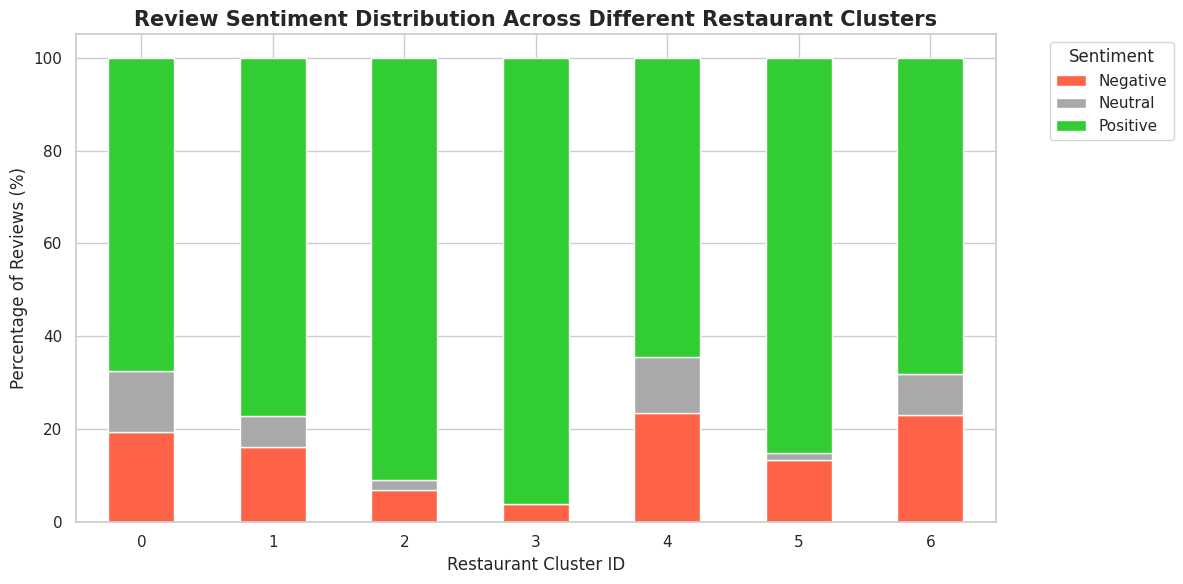

--- Percentage Sentiment Breakdown Per Cluster ---
Sentiment  Negative  Neutral  Positive
Cluster                               
0             19.50    13.00     67.50
1             16.21     6.67     77.12
2              7.00     2.00     91.00
3              4.00     0.00     96.00
4             23.59    11.95     64.46
5             13.38     1.48     85.15
6             23.00     9.00     68.00


In [19]:
# 1. Map the cluster labels from merged_df back to the individual reviews
cluster_mapping = dict(zip(merged_df['Name'], merged_df['Cluster']))
reviews_df['Cluster'] = reviews_df['Restaurant'].map(cluster_mapping)

# Drop any reviews that don't match our clustered restaurants
reviews_df.dropna(subset=['Cluster'], inplace=True)
reviews_df['Cluster'] = reviews_df['Cluster'].astype(int)

# 2. Create a cross-tabulation of Clusters vs Sentiment
cluster_sentiment = pd.crosstab(reviews_df['Cluster'], reviews_df['Sentiment'], normalize='index') * 100

# 3. Plot a stacked bar chart showing sentiment distribution across clusters
cluster_sentiment.plot(kind='bar', stacked=True, figsize=(12, 6), color=['tomato', 'darkgray', 'limegreen'])

plt.title('Review Sentiment Distribution Across Different Restaurant Clusters', fontsize=15, fontweight='bold')
plt.xlabel('Restaurant Cluster ID', fontsize=12)
plt.ylabel('Percentage of Reviews (%)', fontsize=12)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Display the numeric breakdown for exact presentation values
print("--- Percentage Sentiment Breakdown Per Cluster ---")
print(cluster_sentiment.round(2))

In [20]:
print("--- TOP RESTAURANT RECOMMENDATIONS FOR CUSTOMERS ---")

# Iterate through each of our 7 clusters to find the top options
for i in range(optimal_k):
    # Filter restaurants belonging to the current cluster
    cluster_rests = merged_df[merged_df['Cluster'] == i]

    if not cluster_rests.empty:
        # Sort them by the highest rating first
        top_rests = cluster_rests.sort_values(by='Rating', ascending=False).head(2)

        print(f"\n★ Cluster {i} (Avg Cost: ₹{cluster_rests['Cost'].mean():.0f}) ★")
        for index, row in top_rests.iterrows():
            print(f"  ⭐ {row['Name']} | Rating: {row['Rating']} | Cost: ₹{row['Cost']}")

--- TOP RESTAURANT RECOMMENDATIONS FOR CUSTOMERS ---

★ Cluster 0 (Avg Cost: ₹762) ★
  ⭐ Hyderabadi Daawat | Rating: 3.83 | Cost: ₹600.0
  ⭐ Yum Yum Tree - The Arabian Food Court | Rating: 3.56 | Cost: ₹1200.0

★ Cluster 1 (Avg Cost: ₹517) ★
  ⭐ KS Bakers | Rating: 3.965 | Cost: ₹200.0
  ⭐ Amul | Rating: 3.94 | Cost: ₹150.0

★ Cluster 2 (Avg Cost: ₹1500) ★
  ⭐ The Fisherman's Wharf | Rating: 4.22 | Cost: ₹1500.0

★ Cluster 3 (Avg Cost: ₹2000) ★
  ⭐ The Indi Grill | Rating: 4.6 | Cost: ₹1500.0
  ⭐ Feast - Sheraton Hyderabad Hotel | Rating: 4.22 | Cost: ₹2500.0

★ Cluster 4 (Avg Cost: ₹617) ★
  ⭐ Paradise | Rating: 4.7 | Cost: ₹800.0
  ⭐ NorFest - The Dhaba | Rating: 4.03 | Cost: ₹550.0

★ Cluster 5 (Avg Cost: ₹1323) ★
  ⭐ AB's - Absolute Barbecues | Rating: 4.88 | Cost: ₹1500.0
  ⭐ B-Dubs | Rating: 4.81 | Cost: ₹1600.0

★ Cluster 6 (Avg Cost: ₹800) ★
  ⭐ Shanghai Chef 2 | Rating: 3.06 | Cost: ₹800.0
